## Part 1 – CNN for Image Classification

In [1]:
# ===== Part 1: Image Classification =====
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Paths (update with your dataset folder paths)
train_dir = "/content/dataset_hist_structures 2.zip"
test_dir = "/content/dataset_hist_structures 2.zip"

In [4]:
import zipfile
import os

zip_path = "/content/dataset_hist_structures 2.zip"
extract_path = "/content/Datasets_extracted"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted {zip_path} to {extract_path}")

Extracted /content/dataset_hist_structures 2.zip to /content/Datasets_extracted


In [5]:
# 1. Visualize sample images
datagen = ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow_from_directory("/content/Datasets_extracted/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset", target_size=(224, 224), batch_size=32, class_mode="categorical")

classes = list(train_gen.class_indices.keys())
print("Classes:", classes)

Found 10235 images belonging to 10 classes.
Classes: ['altar', 'apse', 'bell_tower', 'column', 'dome(inner)', 'dome(outer)', 'flying_buttress', 'gargoyle', 'stained_glass', 'vault']


Category: flying_buttress


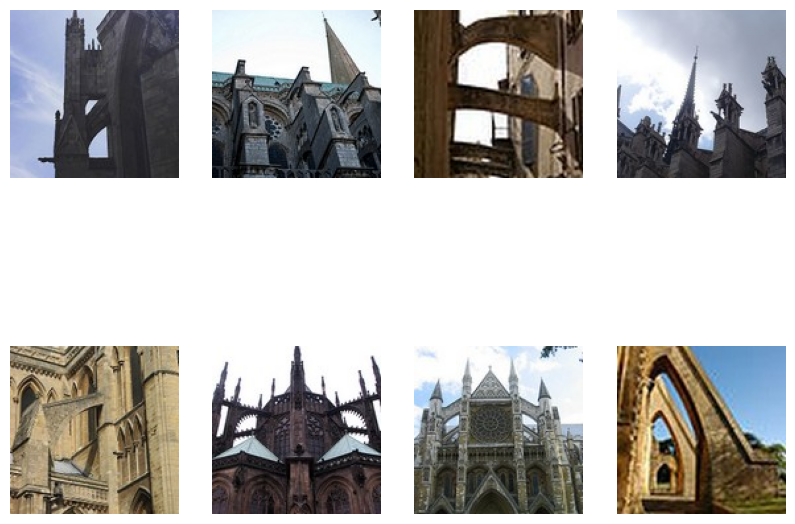

Category: altar


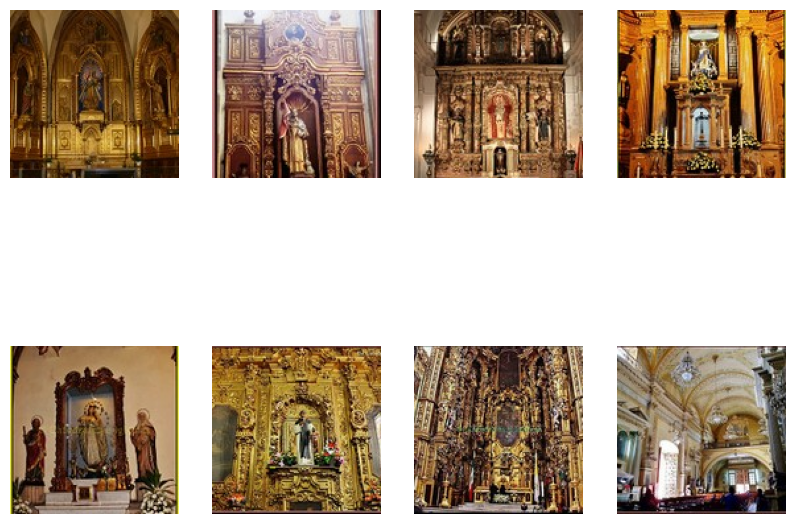

Category: apse


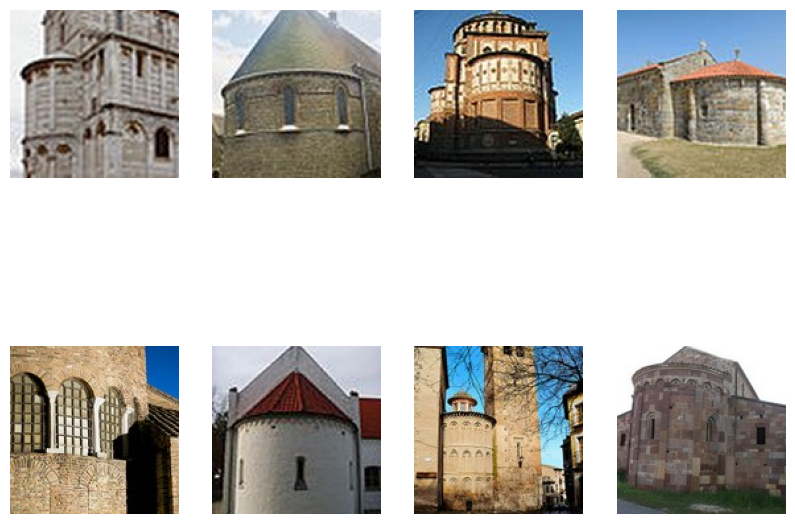

Category: gargoyle


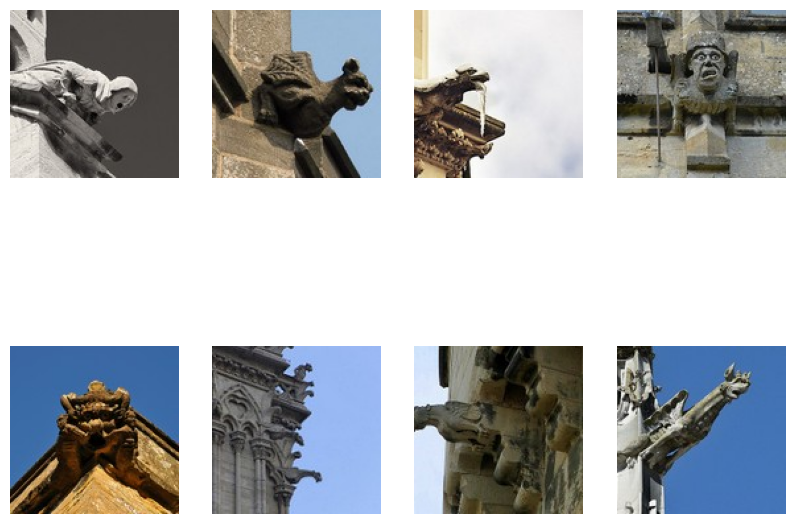

Category: column


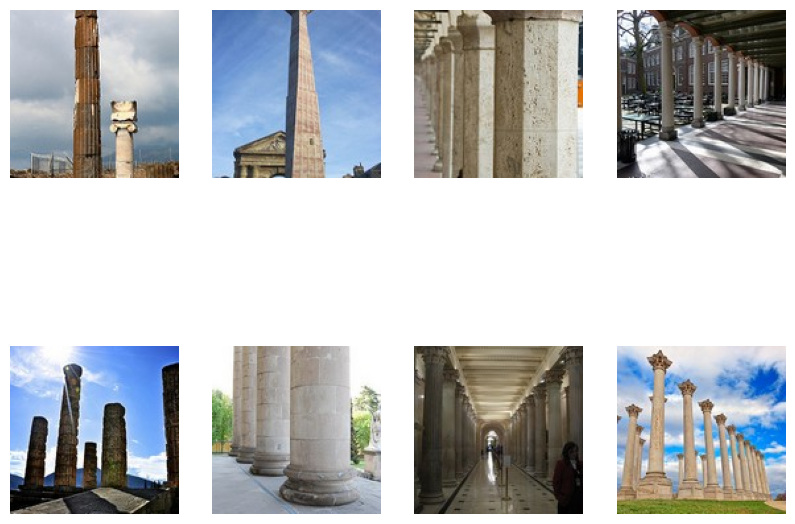

Category: dome(outer)


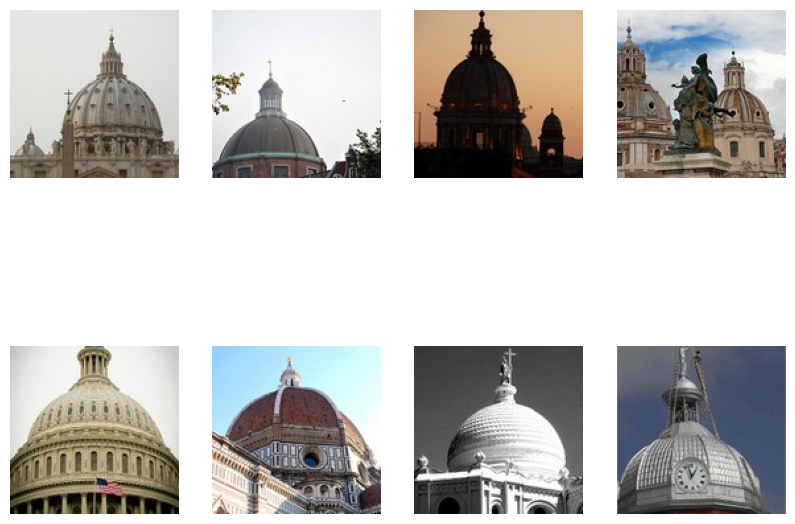

Category: vault


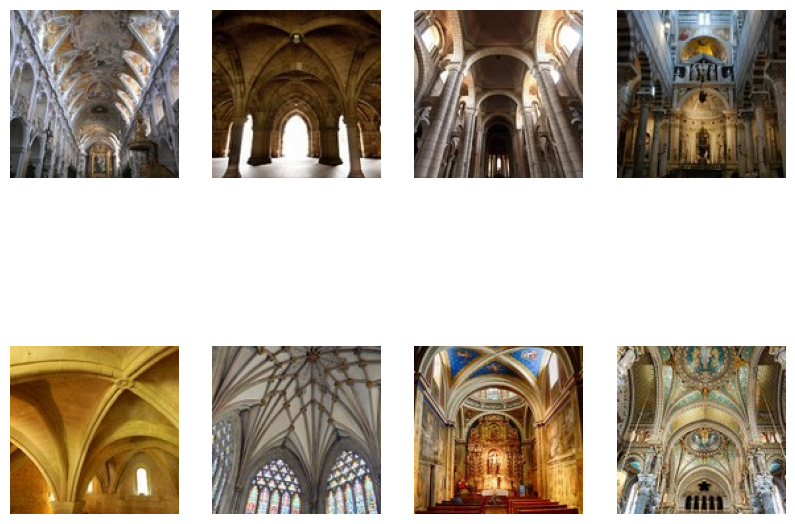

Category: bell_tower


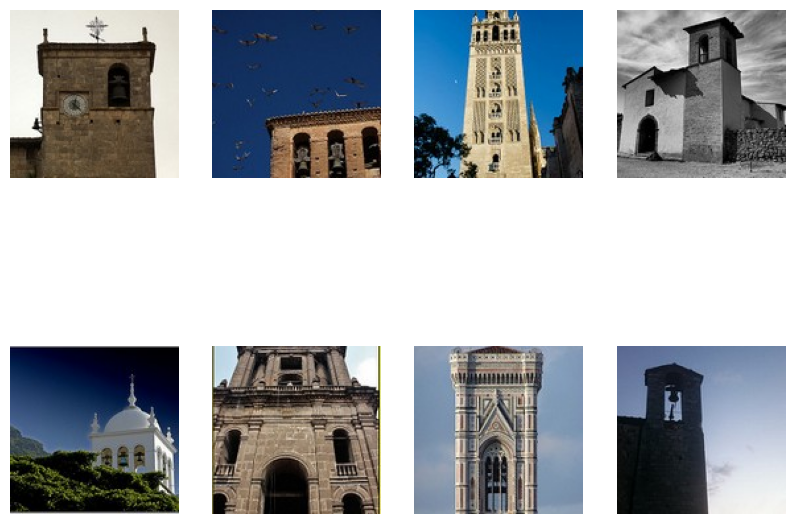

Category: stained_glass


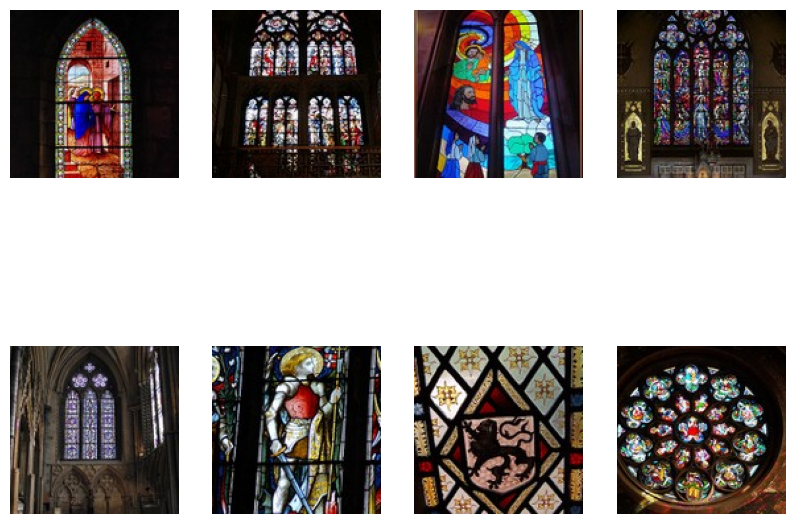

Category: dome(inner)


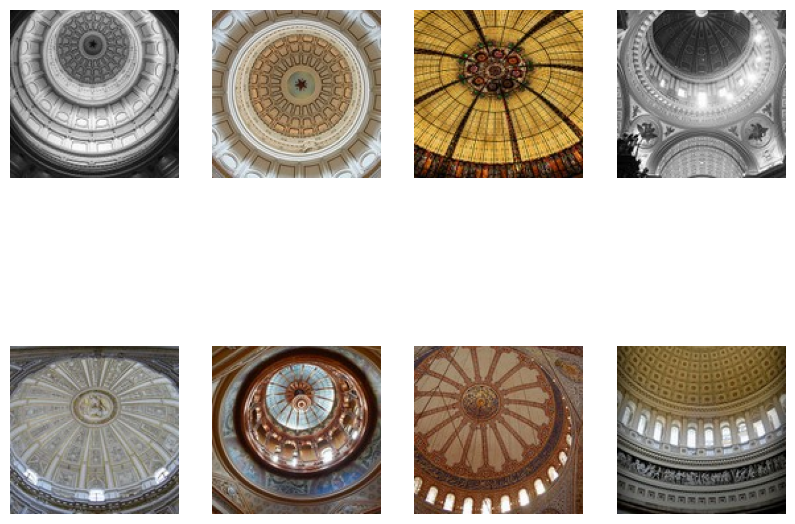

In [6]:
import cv2 # Import cv2

data_path = "/content/Datasets_extracted/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset"
# List all the subdirectories
categories = [category for category in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, category)) and not category.startswith('.')]

# Plot sample images from each category
for category in categories:
    category_path = os.path.join(data_path, category)
    images = [image for image in os.listdir(category_path) if not image.startswith('.')]
    print(f"Category: {category}")
    plt.figure(figsize=(10, 8))
    for i in range(min(8, len(images))):
        image = cv2.imread(os.path.join(category_path, images[i]))
        # Check if image is loaded successfully
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            plt.subplot(2, 4, i + 1)
            plt.imshow(image)
            plt.axis('off')
    plt.show()

In [7]:
# 2. Transfer Learning with VGG16
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
for layer in base_model.layers:
    layer.trainable = False  # freeze layers

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# 3. Modify the final layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(len(classes), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

In [9]:
# 4. Compile
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [10]:
# 5. Callbacks
early_stop = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

In [11]:
# 7. Train without augmentation
history_no_aug = model.fit(train_gen, validation_data=train_gen, epochs=10, callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 124s 344ms/step - accuracy: 0.5817 - loss: 1.3221 - val_accuracy: 0.8850 - val_loss: 0.4147
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 134s 418ms/step - accuracy: 0.8619 - loss: 0.4570 - val_accuracy: 0.9161 - val_loss: 0.2917
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 104s 324ms/step - accuracy: 0.8918 - loss: 0.3600 - val_accuracy: 0.9234 - val_loss: 0.2493
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 134s 420ms/step - accuracy: 0.9007 - loss: 0.3106 - val_accuracy: 0.9298 - val_loss: 0.2289
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 134s 419ms/step - accuracy: 0.9200 - loss: 0.2719 - val_accuracy: 0.9327 - val_loss: 0.2093
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 103s 324ms/step - accuracy: 0.9165 - loss: 0.2592 - val_accuracy: 0.9408 - val_loss: 0.1861
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 104s 326ms/step - accuracy: 0.9179 - loss: 0.2440 - val_accuracy: 0.9450 - val_loss: 0.1722
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 104s 326ms/step - accuracy: 0.9226 -

In [ ]:
# 8. Train with augmentation
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
).flow_from_directory(train_dir, target_size=(224,224), batch_size=32, class_mode="categorical")

history_aug = model.fit(train_aug, validation_data=train_gen, epochs=5, callbacks=[early_stop])

Found 10235 images belonging to 10 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 200s 617ms/step - accuracy: 0.5194 - loss: 1.5063 - val_accuracy: 0.8343 - val_loss: 0.5519
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 196s 614ms/step - accuracy: 0.8073 - loss: 0.6093 - val_accuracy: 0.8858 - val_loss: 0.3689
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 196s 611ms/step - accuracy: 0.8338 - loss: 0.4878 - val_accuracy: 0.8997 - val_loss: 0.3147
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 194s 607ms/step - accuracy: 0.8660 - loss: 0.4223 - val_accuracy: 0.9088 - val_loss: 0.2830
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 191s 599ms/step - accuracy: 0.8746 - loss: 0.3965 - val_accuracy: 0.9154 - val_loss: 0.2641
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 194s 606ms/step - accuracy: 0.8670 - loss: 0.3904 - val_accuracy: 0.9101 - val_loss: 0.2684
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 194s 608ms/step - accuracy: 0.8797 - loss: 0.3600 - val_accuracy: 0.9196 - val_loss: 0.2411
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 194s 606ms/step - accuracy: 0.8814 -

In [ ]:
# 8. Plot accuracy curves
plt.plot(history_aug.history["accuracy"], label="train_acc")
plt.plot(history_aug.history["val_accuracy"], label="val_acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

NameError: name 'plt' is not defined

## Part 2 – Recommendation Engine

In [ ]:
# ===== Part 2: Recommendation System =====
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# 1. Load datasets
users = pd.read_csv("user.csv")
places = pd.read_excel("tourism_with_id.xlsx")
ratings = pd.read_csv("tourism_rating.csv")

print(users.head())
print(places.head())
print(ratings.head())

In [ ]:
# 2. Merge ratings with places
data = pd.merge(ratings, places, on="Place_id")
print(data.head())

In [ ]:
# 3. Most loved places
top_places = data.groupby("Place_name")["place_rating"].mean().sort_values(ascending=False).head(10)
print("Top Rated Places:\n", top_places)

In [ ]:
# 4. Content-based recommendation (using TF-IDF on Description)
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(places["Description"].fillna(""))

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(places.index, index=places["Place_name"]).drop_duplicates()

def recommend_place(place_name, top_n=5):
    idx = indices[place_name]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    place_indices = [i[0] for i in sim_scores]
    return places["Place_name"].iloc[place_indices]

print("\nRecommendations for 'Taman Mini Indonesia Indah':")
print(recommend_place("Taman Mini Indonesia Indah"))

In [ ]:
# 5. Collaborative Filtering (User-Item Matrix)
user_item_matrix = ratings.pivot(index="user_id", columns="place_id", values="place_rating").fillna(0)

cosine_sim_users = cosine_similarity(user_item_matrix)
cosine_sim_df = pd.DataFrame(cosine_sim_users, index=user_item_matrix.index, columns=user_item_matrix.index)

def recommend_for_user(user_id, top_n=5):
    sim_users = cosine_sim_df[user_id].sort_values(ascending=False)[1:6].index
    sim_ratings = user_item_matrix.loc[sim_users].mean().sort_values(ascending=False)
    return sim_ratings.head(top_n)

print("\nRecommendations for User 1:")
print(recommend_for_user(1))